In [1]:
import cv2
import time
import matplotlib.pyplot as plt
import os

from huggingface_hub import hf_hub_download

### Hugging Face에서 YuNet 가중치 파일 다운로드

AuraFace 등 기존 노트북 방식과의 일관성을 위해 `notebook/models/yunet/` 폴더 내에 다운로드합니다.
CV Zoo 저장소(`opencv/cv_zoo`)에는 수많은 모델이 있으므로, `hf_hub_download`를 이용해 YuNet ONNX 파일만 효율적으로 내려받습니다.

In [2]:
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(
    repo_id="opencv/face_detection_yunet",
    filename="face_detection_yunet_2023mar.onnx"
)

print(model_path)

C:\Users\wonbin\.cache\huggingface\hub\models--opencv--face_detection_yunet\snapshots\3cc26e7f1014a5ee5d74a42acee58bafc9d0a310\face_detection_yunet_2023mar.onnx


In [3]:
import os

print(model_path)
print(os.path.exists(model_path))

C:\Users\wonbin\.cache\huggingface\hub\models--opencv--face_detection_yunet\snapshots\3cc26e7f1014a5ee5d74a42acee58bafc9d0a310\face_detection_yunet_2023mar.onnx
True


### 이미지 다운 후, 랜드마크 추출

In [4]:
import cv2

img = cv2.imread("../images/test1.jpg")

h, w = img.shape[:2]

detector = cv2.FaceDetectorYN.create(
    model=model_path,
    config="",
    input_size=(w, h),
    score_threshold=0.7,
    nms_threshold=0.3,
    top_k=5000
)

_, faces = detector.detect(img)
for i, face in enumerate(faces):

    x, y, w_box, h_box = face[:4]

    print(f"\nFace {i}")
    print(f"BBox : ({x:.1f}, {y:.1f}, {w_box:.1f}, {h_box:.1f})")

    landmarks = face[4:14].reshape(5, 2)

    print("Landmarks")
    print(landmarks)

print(faces.shape)


Face 0
BBox : (56.3, 174.5, 23.5, 29.8)
Landmarks
[[ 62.30041  185.20146 ]
 [ 73.3791   185.62378 ]
 [ 67.53187  191.32716 ]
 [ 63.591827 194.39478 ]
 [ 72.31575  196.55849 ]]

Face 1
BBox : (261.5, 189.6, 20.5, 26.9)
Landmarks
[[265.30194 199.29576]
 [274.1701  199.1519 ]
 [269.14804 204.21318]
 [267.1247  210.5951 ]
 [273.7629  208.44855]]

Face 2
BBox : (162.0, 173.9, 21.9, 27.1)
Landmarks
[[168.88304 184.68674]
 [179.0086  184.64291]
 [175.02127 190.1135 ]
 [169.9102  193.78204]
 [178.05234 194.65038]]

Face 3
BBox : (207.7, 176.3, 22.6, 27.7)
Landmarks
[[211.68529 186.97083]
 [221.58282 186.89357]
 [215.33334 192.83844]
 [213.15562 197.13173]
 [221.14621 197.24477]]

Face 4
BBox : (310.0, 174.0, 24.0, 28.9)
Landmarks
[[313.27234 184.03221]
 [324.23987 183.84277]
 [316.50824 189.36708]
 [314.32394 195.6843 ]
 [323.14893 194.62524]]

Face 5
BBox : (119.7, 190.4, 20.4, 25.8)
Landmarks
[[125.23872 200.49559]
 [134.22299 200.7399 ]
 [129.38892 206.15941]
 [125.78648 210.15584]
 [132.4

### 얼굴 사진 추출

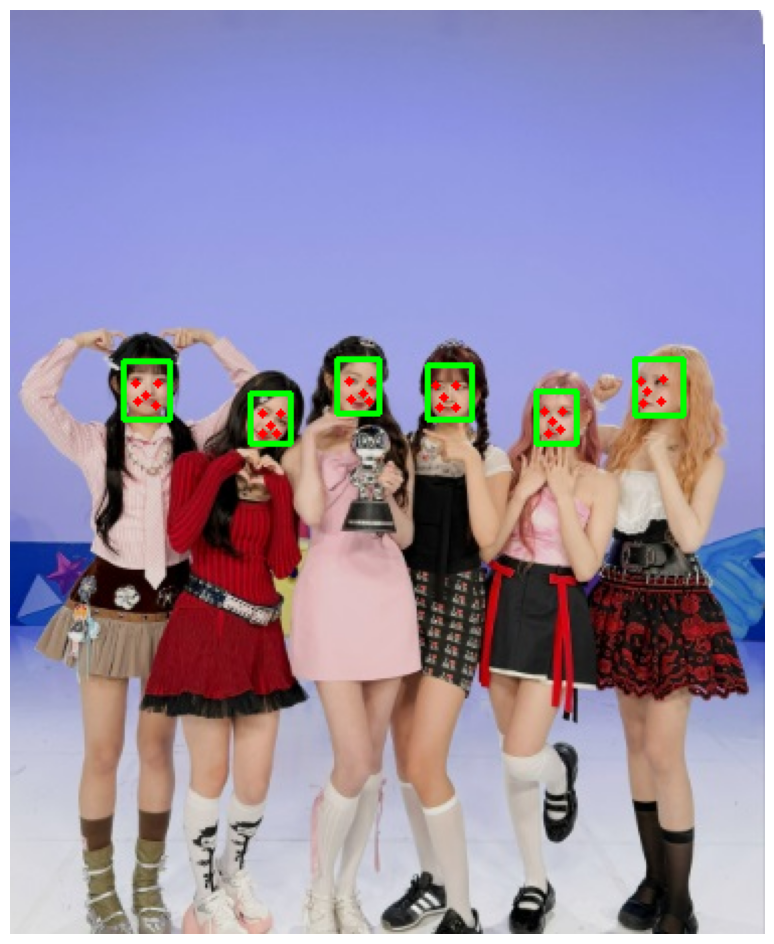

In [5]:
import cv2
import matplotlib.pyplot as plt

vis = img.copy()

for face in faces:

    x, y, w_box, h_box = face[:4].astype(int)

    # bbox
    cv2.rectangle(
        vis,
        (x, y),
        (x + w_box, y + h_box),
        (0, 255, 0),
        2
    )

    # landmarks
    landmarks = face[4:14].reshape(5, 2)

    for px, py in landmarks.astype(int):
        cv2.circle(
            vis,
            (px, py),
            2,
            (0, 0, 255),
            -1
        )

plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()